# OpportunityOS - model evaluation walkthrough

Reproduces and explains the evaluation of the **30-day cash-pressure model** and compares it with
(1) a rule of thumb that only looks at the cash buffer and (2) the hackathon-provided dataset.

All data here is **synthetic** (generated by `scripts/generate_synthetic.py`) except `data/public/small_business_cashflow.csv`,
which is used only as a benchmark. Numbers are read from the artefacts written by `ml/train_cash_pressure.py`,
so this notebook cannot drift from what the app shows.

In [1]:
import json, sys
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'backend'))
from app.analytics.features import FEATURE_NAMES, FEATURE_LABELS
meta = json.loads((ROOT / 'models/cash_pressure/metadata.json').read_text())
panel = pd.read_csv(ROOT / 'data/synthetic/cash_pressure_panel.csv', parse_dates=['as_of'])
print(meta['version'], '|', meta['algorithm'])
print(meta['target']['definition'])
print(meta['target']['eligibility'])

cash-pressure-20260923-aa1d40 | logistic_regression_C1
Cash balance falls below 14 days of committed outflows at any point in the next 30 days
Applied only when current buffer_days >= 14; below that the deterministic engine reports existing pressure instead of predicting it.


## 1. The panel
One row per synthetic business per fortnight. The label looks 30 days ahead on the actual simulated cash path.

In [2]:
elig = panel[panel.buffer_days >= 14]
print(f"{len(panel):,} rows, {panel.business_key.nunique()} businesses, {len(elig):,} eligible (buffer >= 14 days)")
elig.groupby('archetype').label.agg(['count', 'mean']).rename(columns={'mean': 'positive_rate'}).round(3)

14,280 rows, 210 businesses, 12,579 eligible (buffer >= 14 days)


,count,positive_rate
archetype,,
clothing,1873,0.089
electronics,1840,0.142
restaurant,1917,0.090
retail_shop,1810,0.108
salon,1935,0.060
service_company,1956,0.073
wholesaler,1248,0.301


## 2. Why ML at all? Compare with the buffer-days rule of thumb
The strongest single signal is the current cash buffer. The model must beat a rule that uses only that.

In [3]:
rows = [
  ('Cross-validation (GroupKFold)', meta['cross_validation']['candidates'][meta['algorithm']]['roc_auc_mean'], meta['cross_validation']['baseline_buffer_days']['roc_auc']),
  ('Held-out businesses', meta['test']['roc_auc'], meta['baseline_test']['roc_auc']),
  ('Later period, unseen businesses', meta['temporal_check'].get('roc_auc'), meta['temporal_check'].get('baseline_buffer_days', {}).get('roc_auc')),
]
pd.DataFrame(rows, columns=['evaluation', 'model ROC-AUC', 'buffer-only ROC-AUC']).round(3)

,evaluation,model ROC-AUC,buffer-only ROC-AUC
0,Cross-validation (GroupKFold),0.928,0.911
1,Held-out businesses,0.943,0.911
2,"Later period, unseen businesses",0.925,0.888


In [4]:
t, b = meta['test'], meta['baseline_test']
pd.DataFrame({
  'model @ HIGH threshold': {k: t['at_high_threshold'][k] for k in ('precision','recall','f1')},
  'rule: buffer < 21 days': {k: b['rule_buffer_lt_21_days'][k] for k in ('precision','recall','f1')},
}).round(3)

,model @ HIGH threshold,rule: buffer < 21 days
precision,0.619,0.520
recall,0.768,0.714
f1,0.686,0.602


## 3. Calibration
Probabilities are shown to users, so they should mean what they say.

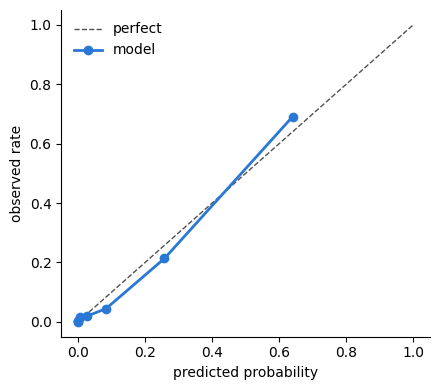

Brier score: 0.0568


In [5]:
cal = pd.DataFrame(meta['test']['calibration_bins'])
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.plot([0, 1], [0, 1], ls='--', c='#52514e', lw=1, label='perfect')
ax.plot(cal.mean_predicted, cal.observed_rate, marker='o', c='#2a78d6', lw=2, label='model')
ax.set_xlabel('predicted probability'); ax.set_ylabel('observed rate'); ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()
print('Brier score:', meta['test']['brier'])

## 4. Confusion matrix and learned weights

In [6]:
cm = meta['test']['at_high_threshold']['confusion_matrix']
display(pd.DataFrame([[cm['tn'], cm['fp']], [cm['fn'], cm['tp']]], index=['actual no', 'actual yes'], columns=['pred no', 'pred yes']))
coef = pd.Series(meta['explainability']['coefficients']).rename(index=FEATURE_LABELS).sort_values(key=abs, ascending=False)
coef.round(3).to_frame('standardised weight')

,pred no,pred yes
actual no,2055,147
actual yes,72,239


,standardised weight
Cash buffer (days of outflows),-7.917
Known obligations due in next 30 days vs monthly outflows,1.396
Recurring expenses as share of outflows,-0.961
Largest customer's share of revenue,0.791
Overdue receivables vs monthly revenue,-0.333
Average days to collect invoices,0.309
"Revenue growth, last 30 days vs prior run-rate",0.269
Change in transaction frequency,-0.187
Weekly cash-flow volatility,-0.165
Cash change over last 30 days vs monthly outflows,0.112


## 5. The provided dataset
Every model is close to chance on the provided file: each row is an isolated monthly snapshot with no business id, so trends cannot be computed.

In [7]:
bm = json.loads((ROOT / 'models/benchmark_provided_csv.json').read_text())
display(pd.DataFrame(bm['models']).T.round(3))
print(bm['finding'])

,roc_auc_mean,roc_auc_std
logistic_regression,0.574,0.025
random_forest,0.524,0.043
hist_gradient_boosting,0.536,0.011


All models score close to chance (ROC-AUC ~0.5-0.6). Each row is an independent snapshot without a business identifier or history, so trend features cannot be derived. We therefore use this file as an external benchmark only and train the production model on a documented synthetic panel with full ledger history.


## 6. Limitations
* Trained on synthetic data: real-world performance is unknown until validated on real SME ledgers.
* The label depends on the generator's assumptions about shocks and owner behaviour.
* Cash-basis ledger only; unrecorded payables are invisible to the model.
* The model is a decision aid: every prediction ships with its drivers and the deterministic projection.